In [1]:
!pip install requests pandas matplotlib


In [2]:
%%writefile suricata_eve_sample.json
{"timestamp":"2026-03-10T10:00:00","event_type":"alert","src_ip":"185.10.10.10","alert":{"signature":"Possible Malware C2 Traffic","severity":1}}
{"timestamp":"2026-03-10T10:01:00","event_type":"alert","src_ip":"91.200.12.34","alert":{"signature":"Nmap Scan Detected","severity":2}}
{"timestamp":"2026-03-10T10:02:00","event_type":"dns","dns":{"rrname":"suspicious-domain.com"}}
{"timestamp":"2026-03-10T10:02:10","event_type":"dns","dns":{"rrname":"suspicious-domain.com"}}
{"timestamp":"2026-03-10T10:02:20","event_type":"dns","dns":{"rrname":"suspicious-domain.com"}}
{"timestamp":"2026-03-10T10:03:00","event_type":"dns","dns":{"rrname":"google.com"}}

Writing suricata_eve_sample.json


In [5]:
%%writefile final_monitor.py
import json
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import requests

SURICATA_LOG = "suricata_eve_sample.json"

def load_logs():
    events=[]
    with open(SURICATA_LOG) as f:
        for line in f:
            events.append(json.loads(line))
    return events

def analyze_suricata(events):

    findings=[]
    dns_counter=Counter()

    for e in events:

        if e["event_type"]=="alert":

            severity=e["alert"]["severity"]

            findings.append({
                "source":"suricata",
                "indicator":e["src_ip"],
                "details":e["alert"]["signature"],
                "severity":severity,
                "action":"block IP" if severity>=2 else "notify"
            })

        if e["event_type"]=="dns":

            domain=e["dns"]["rrname"]
            dns_counter[domain]+=1

    for domain,count in dns_counter.items():

        if count>=3:

            findings.append({
                "source":"suricata",
                "indicator":domain,
                "details":"frequent DNS request",
                "severity":2,
                "action":"block domain"
            })

    return findings

def vulners_demo():

    return[
        {"source":"vulners","indicator":"CVE-2024-0001","details":"Critical vulnerability","severity":9,"action":"patch system"},
        {"source":"vulners","indicator":"CVE-2024-0002","details":"High vulnerability","severity":8,"action":"update software"}
    ]

def main():

    events=load_logs()

    findings=analyze_suricata(events)

    findings+=vulners_demo()

    df=pd.DataFrame(findings)

    df.to_csv("threat_report.csv",index=False)

    print("Threats found:",len(df))

    print(df)

    df["source"].value_counts().plot(kind="bar")

    plt.title("Threat sources")

    plt.savefig("threat_chart.png")

main()

Overwriting final_monitor.py


In [6]:
!python final_monitor.py

Threats found: 5
     source              indicator  ... severity           action
0  suricata           185.10.10.10  ...        1           notify
1  suricata           91.200.12.34  ...        2         block IP
2  suricata  suspicious-domain.com  ...        2     block domain
3   vulners          CVE-2024-0001  ...        9     patch system
4   vulners          CVE-2024-0002  ...        8  update software

[5 rows x 5 columns]


In [7]:
import pandas as pd
pd.read_csv("threat_report.csv")

,source,indicator,details,severity,action
0,suricata,185.10.10.10,Possible Malware C2 Traffic,1,notify
1,suricata,91.200.12.34,Nmap Scan Detected,2,block IP
2,suricata,suspicious-domain.com,frequent DNS request,2,block domain
3,vulners,CVE-2024-0001,Critical vulnerability,9,patch system
4,vulners,CVE-2024-0002,High vulnerability,8,update software


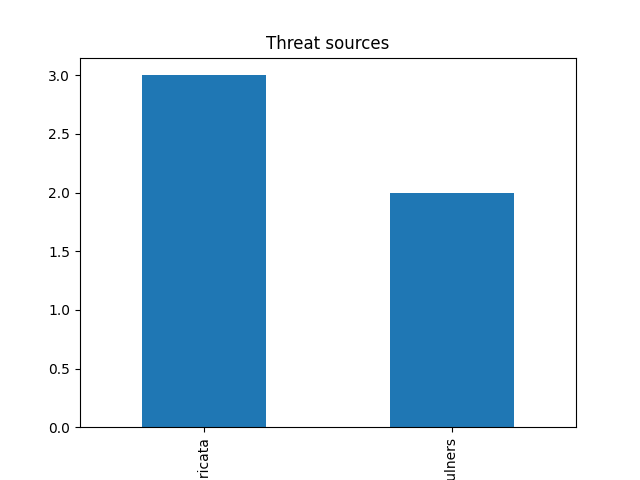

In [8]:
from IPython.display import Image
Image("threat_chart.png")